## FEATURE EXTRACTION FROM AUDIO FILES

In [1]:
# Import required libraries for feature extraction
import os
import librosa
import soundfile as sf
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Optional, List
from pydub import AudioSegment

# ===== CONFIGURATION =====
SAMPLE_RATE = 16000  # Hz
MFCC_N_COEFFICIENTS = 13
F0_MIN_FREQUENCY = 50  # Hz
F0_MAX_FREQUENCY = 300  # Hz

# Paths
DATASET_DIR = os.path.join(os.getcwd(), "dataset", "extracted_syllables_consolidated")
OUTPUT_CSV_PATH = os.path.join(os.getcwd(), "dataset", "syllable_features.csv")

print(f"📂 Dataset Directory: {DATASET_DIR}")
print(f"💾 Output CSV Path: {OUTPUT_CSV_PATH}")

# ===== FEATURE EXTRACTION FUNCTIONS =====
def extract_features_from_audio_file(audio_path: str, sr: int = SAMPLE_RATE) -> Optional[Dict]:
    """
    Ekstraksi fitur audio dari file audio.
    
    Fitur yang diekstraksi:
    - Duration
    - Zero Crossing Rate (ZCR)
    - RMS Energy
    - Spectral Centroid
    - MFCC (13 coefficients) mean and std
    - F0 (Fundamental Frequency) mean
    
    Args:
        audio_path: Path ke file audio
        sr: Sampling rate
        
    Returns:
        Dictionary berisi features, atau None jika error
    """
    try:
        # Load audio dengan specified sample rate
        y, _ = librosa.load(audio_path, sr=sr)
        
        if len(y) == 0:
            print(f"    ⚠️  Audio kosong: {audio_path}")
            return None
        
        duration = len(y) / sr
        
        # Extract features
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        rms = np.sqrt(np.mean(y**2))
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        
        # MFCC features
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=MFCC_N_COEFFICIENTS)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        
        # Fundamental frequency
        f0, _, _ = librosa.pyin(y, fmin=F0_MIN_FREQUENCY, fmax=F0_MAX_FREQUENCY, sr=sr)
        f0_mean = np.nanmean(f0)
        
        features = {
            "duration_sec": float(duration),
            "zcr": float(zcr),
            "rms": float(rms),
            "spectral_centroid": float(spec_cent),
            "f0_mean": float(f0_mean) if not np.isnan(f0_mean) else 0.0,
        }
        
        # Add MFCC coefficients
        for i in range(MFCC_N_COEFFICIENTS):
            features[f"mfcc_{i+1}_mean"] = float(mfcc_mean[i])
            features[f"mfcc_{i+1}_std"] = float(mfcc_std[i])
        
        return features
        
    except Exception as e:
        print(f"    ❌ Error extracting features from {os.path.basename(audio_path)}: {str(e)}")
        return None
    
def process_dataset():
    """
    Process semua audio file di dataset folder dan ekstraksi fitur.
    
    Returns:
        DataFrame dengan semua extracted features
    """
    if not os.path.exists(DATASET_DIR):
        print(f"❌ Dataset directory tidak ditemukan: {DATASET_DIR}")
        return None
    
    print(f"📂 Dataset directory: {DATASET_DIR}")
    print(f"🔍 Scanning audio files...\n")
    
    # Collect semua audio files
    audio_files = []
    syllable_labels = []
    
    for label_folder in sorted(os.listdir(DATASET_DIR)):
        label_path = os.path.join(DATASET_DIR, label_folder)
        
        if not os.path.isdir(label_path):
            continue
        
        audio_count = 0
        for audio_file in sorted(os.listdir(label_path)):
            if audio_file.endswith('.wav'):
                audio_path = os.path.join(label_path, audio_file)
                audio_files.append(audio_path)
                syllable_labels.append(label_folder)
                audio_count += 1
        
        print(f"   ✓ Label '{label_folder}': {audio_count} files")
    
    print(f"\n📊 Total audio files: {len(audio_files)}")
    print(f"🚀 Extracting features...\n")
    
    # Extract features
    features_list = []
    filenames = []
    
    for idx, (audio_path, label) in enumerate(zip(audio_files, syllable_labels), 1):
        filename = os.path.basename(audio_path)
        
        # Progress indicator
        if idx % 50 == 0 or idx == len(audio_files):
            print(f"   [{idx}/{len(audio_files)}] Processing {label}/{filename}...")
        
        features = extract_features_from_audio_file(audio_path)
        
        if features is not None:
            features['syllable_label'] = label
            features['filename'] = filename
            features_list.append(features)
            filenames.append(filename)
    
    print(f"\n✅ Feature extraction complete!")
    print(f"   Total features extracted: {len(features_list)}")
    
    # Create DataFrame
    df = pd.DataFrame(features_list)
    
    # Reorder columns - put important columns first
    columns_order = [
        'filename', 'syllable_label', 'duration_sec', 'zcr', 'rms', 
        'spectral_centroid', 'f0_mean'
    ]
    
    # Add MFCC columns in order
    mfcc_columns = [col for col in df.columns if 'mfcc' in col]
    columns_order.extend(sorted(mfcc_columns))
    
    df = df[columns_order]
    
    return df

def save_dataset(df: pd.DataFrame):
    """
    Simpan DataFrame ke CSV file.
    
    Args:
        df: DataFrame untuk disimpan
    """
    if df is None or len(df) == 0:
        print(f"❌ DataFrame kosong, tidak bisa disimpan")
        return
    
    os.makedirs(os.path.dirname(OUTPUT_CSV_PATH), exist_ok=True)
    df.to_csv(OUTPUT_CSV_PATH, index=False)
    
    print(f"\n💾 Dataset saved successfully!")
    print(f"   Output file: {OUTPUT_CSV_PATH}")
    print(f"   Shape: {df.shape}")
    print(f"   Columns: {len(df.columns)}")
    print(f"\n📋 Column names:")
    for i, col in enumerate(df.columns, 1):
        print(f"      {i}. {col}")
    
    print(f"\n📊 Dataset statistics:")
    print(f"   Syllable labels: {df['syllable_label'].nunique()}")
    print(f"\n   Syllable distribution:")
    label_counts = df['syllable_label'].value_counts().sort_index()
    for label, count in label_counts.items():
        print(f"      - {label}: {count} samples")
    
    print(f"\n   Feature statistics (numeric columns):")
    print(df.describe().to_string())

📂 Dataset Directory: c:\Users\ASUS\Documents\CC x DBS 2026 (DS)\Capstone Project\Heartz\data-science2\eda\dataset\extracted_syllables_consolidated
💾 Output CSV Path: c:\Users\ASUS\Documents\CC x DBS 2026 (DS)\Capstone Project\Heartz\data-science2\eda\dataset\syllable_features.csv


In [2]:
# Run feature extraction
print("=" * 80)
print("🎵 FEATURE EXTRACTION FOR EDA")
print("=" * 80 + "\n")

# Check if dataset exists
if not os.path.exists(DATASET_DIR):
    print(f"❌ Error: Dataset directory tidak ditemukan!")
    print(f"   Expected path: {DATASET_DIR}")
else:
    # Process dataset
    df_features = process_dataset()
    
    if df_features is None or len(df_features) == 0:
        print(f"❌ No data extracted!")
    else:
        # Save dataset
        save_dataset(df_features)
        
        print("\n" + "=" * 80)
        print("✅ Feature extraction completed successfully!")
        print("=" * 80)

🎵 FEATURE EXTRACTION FOR EDA

📂 Dataset directory: c:\Users\ASUS\Documents\CC x DBS 2026 (DS)\Capstone Project\Heartz\data-science2\eda\dataset\extracted_syllables_consolidated
🔍 Scanning audio files...

   ✓ Label 'a': 200 files
   ✓ Label 'ba': 200 files
   ✓ Label 'be': 200 files
   ✓ Label 'bi': 200 files
   ✓ Label 'bo': 200 files
   ✓ Label 'bu': 200 files
   ✓ Label 'e': 200 files
   ✓ Label 'i': 200 files
   ✓ Label 'ma': 254 files
   ✓ Label 'me': 200 files
   ✓ Label 'mi': 200 files
   ✓ Label 'mo': 200 files
   ✓ Label 'mu': 200 files
   ✓ Label 'o': 200 files
   ✓ Label 'pa': 200 files
   ✓ Label 'pe': 200 files
   ✓ Label 'pi': 200 files
   ✓ Label 'po': 200 files
   ✓ Label 'pu': 200 files
   ✓ Label 'u': 200 files

📊 Total audio files: 4054
🚀 Extracting features...



c:\Users\ASUS\Documents\CC x DBS 2026 (DS)\Capstone Project\Heartz\data-science2\eda\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10012\1837116514.py:66: RuntimeWarning: Mean of empty slice
  f0_mean = np.nanmean(f0)


   [50/4054] Processing a/a_aug_059.wav...
   [100/4054] Processing a/a_aug_109.wav...
   [150/4054] Processing a/a_aug_159.wav...
   [200/4054] Processing a/apa_41.727_41.987.wav...
   [250/4054] Processing ba/ba_aug_101.wav...
   [300/4054] Processing ba/ba_aug_151.wav...
   [350/4054] Processing ba/bahagia_369.443_369.618.wav...
   [400/4054] Processing ba/sebagai_95.408_95.503.wav...
   [450/4054] Processing be/be_aug_095.wav...
   [500/4054] Processing be/be_aug_145.wav...
   [550/4054] Processing be/be_aug_195.wav...
   [600/4054] Processing be/sebesama_195.663_195.763.wav...
   [650/4054] Processing bi/bi_aug_058.wav...
   [700/4054] Processing bi/bi_aug_108.wav...
   [750/4054] Processing bi/bi_aug_158.wav...
   [800/4054] Processing bi/pubi_453.948_454.098.wav...
   [850/4054] Processing bo/bo_aug_059.wav...
   [900/4054] Processing bo/bo_aug_109.wav...
   [950/4054] Processing bo/bo_aug_159.wav...
   [1000/4054] Processing bo/bombai_176.516_176.723.wav...
   [1050/4054] Proce

# 🎵 Exploratory Data Analysis (EDA) - Syllable Audio Features

## Analisis Komprehensif Dataset Audio Suku Kata Indonesia

### Tujuan:
1. Eksplorasi karakteristik akustik dari berbagai suku kata
2. Identifikasi pola dan variabilitas fitur audio
3. Menganalisis pertanyaan bisnis yang relevan
4. Memberikan insights untuk pengembangan model classification

## 1. SETUP DAN DATA LOADING

In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Load dataset - gunakan features yang sudah diekstraksi atau load dari CSV
print(f"Loading data...")

if 'df_features' in locals() and df_features is not None:
    df = df_features
    print(f"\n✅ Using extracted features from feature extraction process")
else:
    csv_path = os.path.join(os.getcwd(), 'dataset', 'syllable_features.csv')
    print(f"Loading data from: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"\n✅ Data loaded from CSV file")

print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")

Loading data...

✅ Using extracted features from feature extraction process
   Shape: (4054, 33)
   Columns: ['filename', 'syllable_label', 'duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std']


## 2. DATA OVERVIEW DAN STATISTIK DASAR

In [4]:
# Display basic information
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   Total samples: {len(df):,}")
print(f"   Total features: {len(df.columns)}")

# Check for missing values
print(f"\n🔍 Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values detected!")
else:
    print(missing[missing > 0])

# Display unique syllables
syllables = sorted(df['syllable_label'].unique())
print(f"\n🎵 Syllables in dataset ({len(syllables)} unique):")
print(f"   {', '.join(syllables)}")

# Display syllable distribution
print(f"\n📈 Syllable Distribution:")
label_counts = df['syllable_label'].value_counts().sort_index()
for label, count in label_counts.items():
    pct = (count / len(df)) * 100
    bar = '█' * (count // 20)
    print(f"   {label:3} | {bar} {count:4} ({pct:5.1f}%)")

DATASET OVERVIEW

📊 Dataset Shape: (4054, 33)
   Total samples: 4,054
   Total features: 33

🔍 Missing Values:
   ✓ No missing values detected!

🎵 Syllables in dataset (20 unique):
   a, ba, be, bi, bo, bu, e, i, ma, me, mi, mo, mu, o, pa, pe, pi, po, pu, u

📈 Syllable Distribution:
   a   | ██████████  200 (  4.9%)
   ba  | ██████████  200 (  4.9%)
   be  | ██████████  200 (  4.9%)
   bi  | ██████████  200 (  4.9%)
   bo  | ██████████  200 (  4.9%)
   bu  | ██████████  200 (  4.9%)
   e   | ██████████  200 (  4.9%)
   i   | ██████████  200 (  4.9%)
   ma  | ████████████  254 (  6.3%)
   me  | ██████████  200 (  4.9%)
   mi  | ██████████  200 (  4.9%)
   mo  | ██████████  200 (  4.9%)
   mu  | ██████████  200 (  4.9%)
   o   | ██████████  200 (  4.9%)
   pa  | ██████████  200 (  4.9%)
   pe  | ██████████  200 (  4.9%)
   pi  | ██████████  200 (  4.9%)
   po  | ██████████  200 (  4.9%)
   pu  | ██████████  200 (  4.9%)
   u   | ██████████  200 (  4.9%)


In [5]:
# Basic statistics
print("\n" + "="*80)
print("BASIC STATISTICS - NUMERIC FEATURES")
print("="*80)

# Key acoustic features
key_features = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean']
print(f"\n{df[key_features].describe().to_string()}")


BASIC STATISTICS - NUMERIC FEATURES

       duration_sec          zcr          rms  spectral_centroid      f0_mean
count        4054.0  4054.000000  4054.000000        4054.000000  4054.000000
mean            1.0     0.043283     0.064241         558.621867   203.179084
std             0.0     0.037767     0.015302         354.214325    73.997690
min             1.0     0.006302     0.013487         149.176587     0.000000
25%             1.0     0.019768     0.054619         328.265534   183.687714
50%             1.0     0.030487     0.060532         429.754948   218.223602
75%             1.0     0.049988     0.072801         645.752962   251.197068
max             1.0     0.243561     0.206398        2276.776009   298.798454


## 3. ANALISIS FITUR UTAMA (PRIMARY FEATURES)

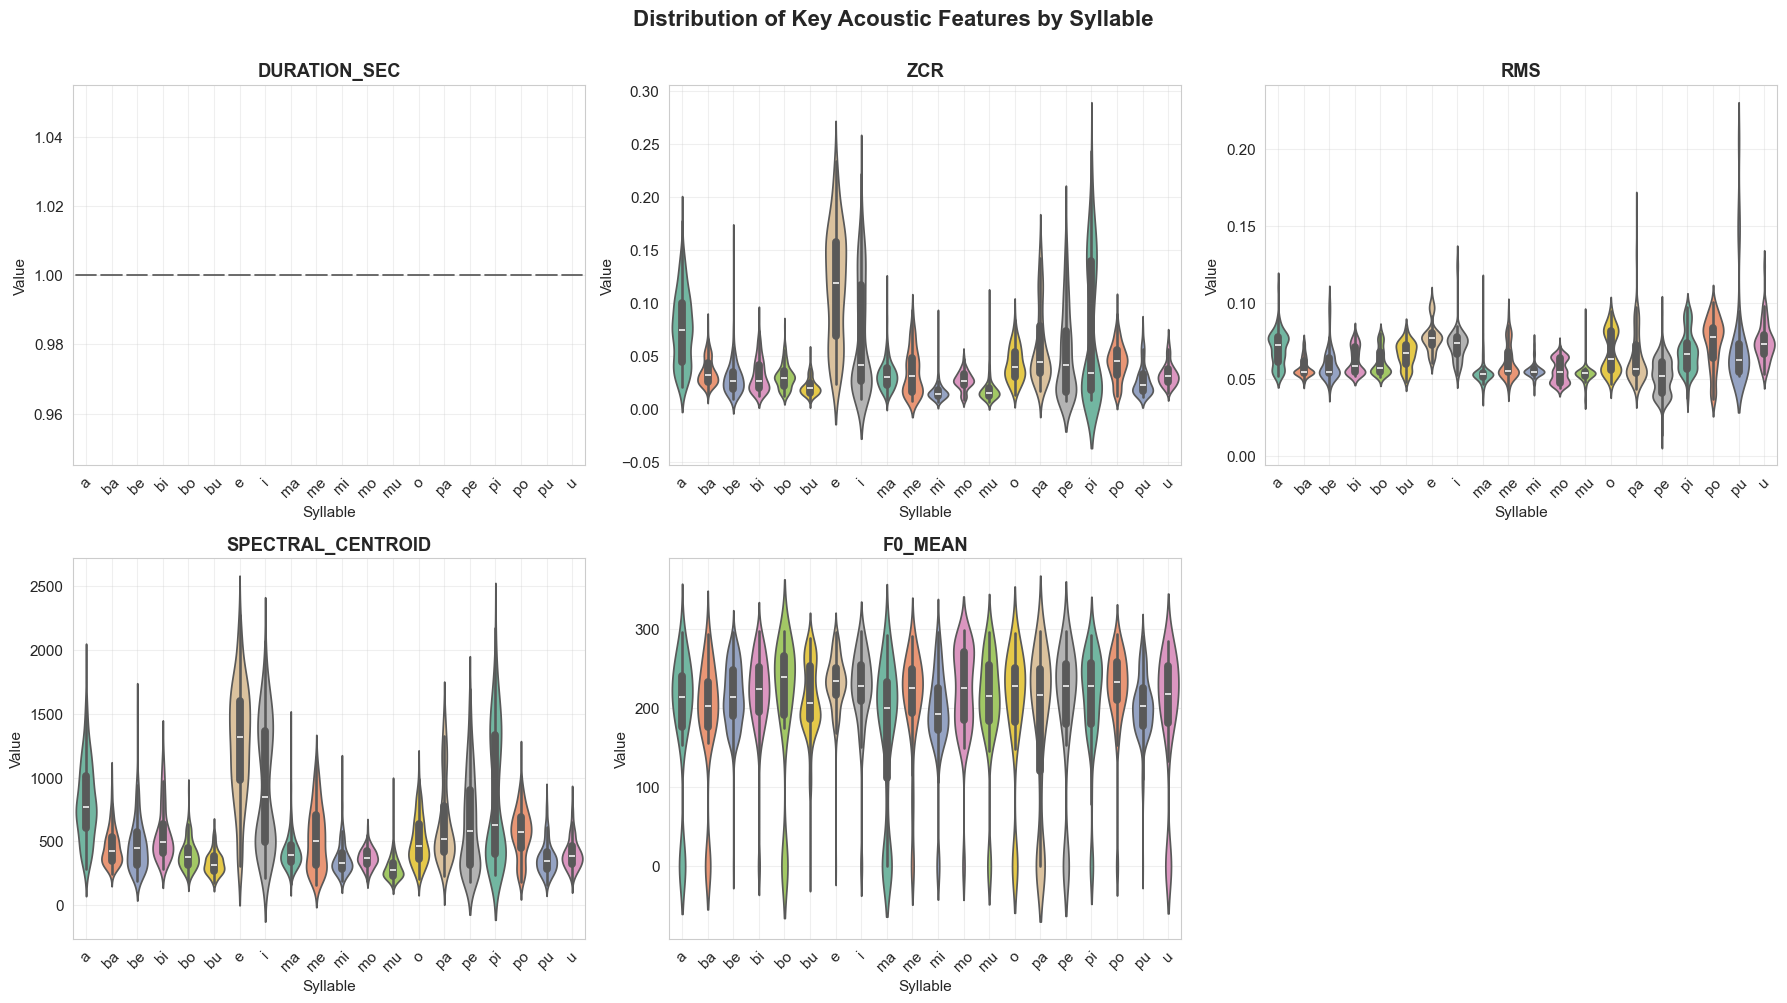

✅ Chart saved as: dataset/figs/01_key_features_distribution.png


In [6]:
# Distribution analysis per syllable untuk fitur kunci
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Key Acoustic Features by Syllable', fontsize=16, fontweight='bold', y=1.00)

key_features = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean']

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    
    # Create violin plot
    sns.violinplot(data=df, x='syllable_label', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature.upper()}', fontweight='bold')
    ax.set_xlabel('Syllable')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# Hide the last subplot (we only have 5 features)
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('dataset/figs/01_key_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as: dataset/figs/01_key_features_distribution.png")

## 4. ANALISIS MFCC (Mel-Frequency Cepstral Coefficients)

In [7]:
# Analisis MFCC coefficients
mfcc_mean_cols = [col for col in df.columns if 'mfcc' in col and 'mean' in col]
mfcc_std_cols = [col for col in df.columns if 'mfcc' in col and 'std' in col]

print("="*80)
print("MFCC ANALYSIS")
print("="*80)
print(f"\n📊 MFCC Mean Coefficients: {len(mfcc_mean_cols)} coefficients")
print(f"   MFCC Std Coefficients: {len(mfcc_std_cols)} coefficients")
print(f"\n   MFCC Mean Statistics:")
print(df[mfcc_mean_cols].describe().to_string())

MFCC ANALYSIS

📊 MFCC Mean Coefficients: 13 coefficients
   MFCC Std Coefficients: 13 coefficients

   MFCC Mean Statistics:
       mfcc_10_mean  mfcc_11_mean  mfcc_12_mean  mfcc_13_mean  mfcc_1_mean  mfcc_2_mean  mfcc_3_mean  mfcc_4_mean  mfcc_5_mean  mfcc_6_mean  mfcc_7_mean  mfcc_8_mean  mfcc_9_mean
count   4054.000000   4054.000000   4054.000000   4054.000000  4054.000000  4054.000000  4054.000000  4054.000000  4054.000000  4054.000000  4054.000000  4054.000000  4054.000000
mean      -5.892127     -5.900837     -4.445755     -4.589251  -481.187119    66.136349   -16.371859     5.020802   -16.311072    -6.835668    -5.580907   -10.489921    -4.013719
std        6.064494      5.898487      5.390881      5.621361    53.277972    28.046330    25.192041    22.994667    18.320831    11.758448     9.172448     9.129839     6.624762
min      -37.187996    -34.680435    -39.575958    -36.334415  -686.574280    -5.121886  -150.567780   -57.944313   -98.540192   -64.922134   -47.343536   -56.

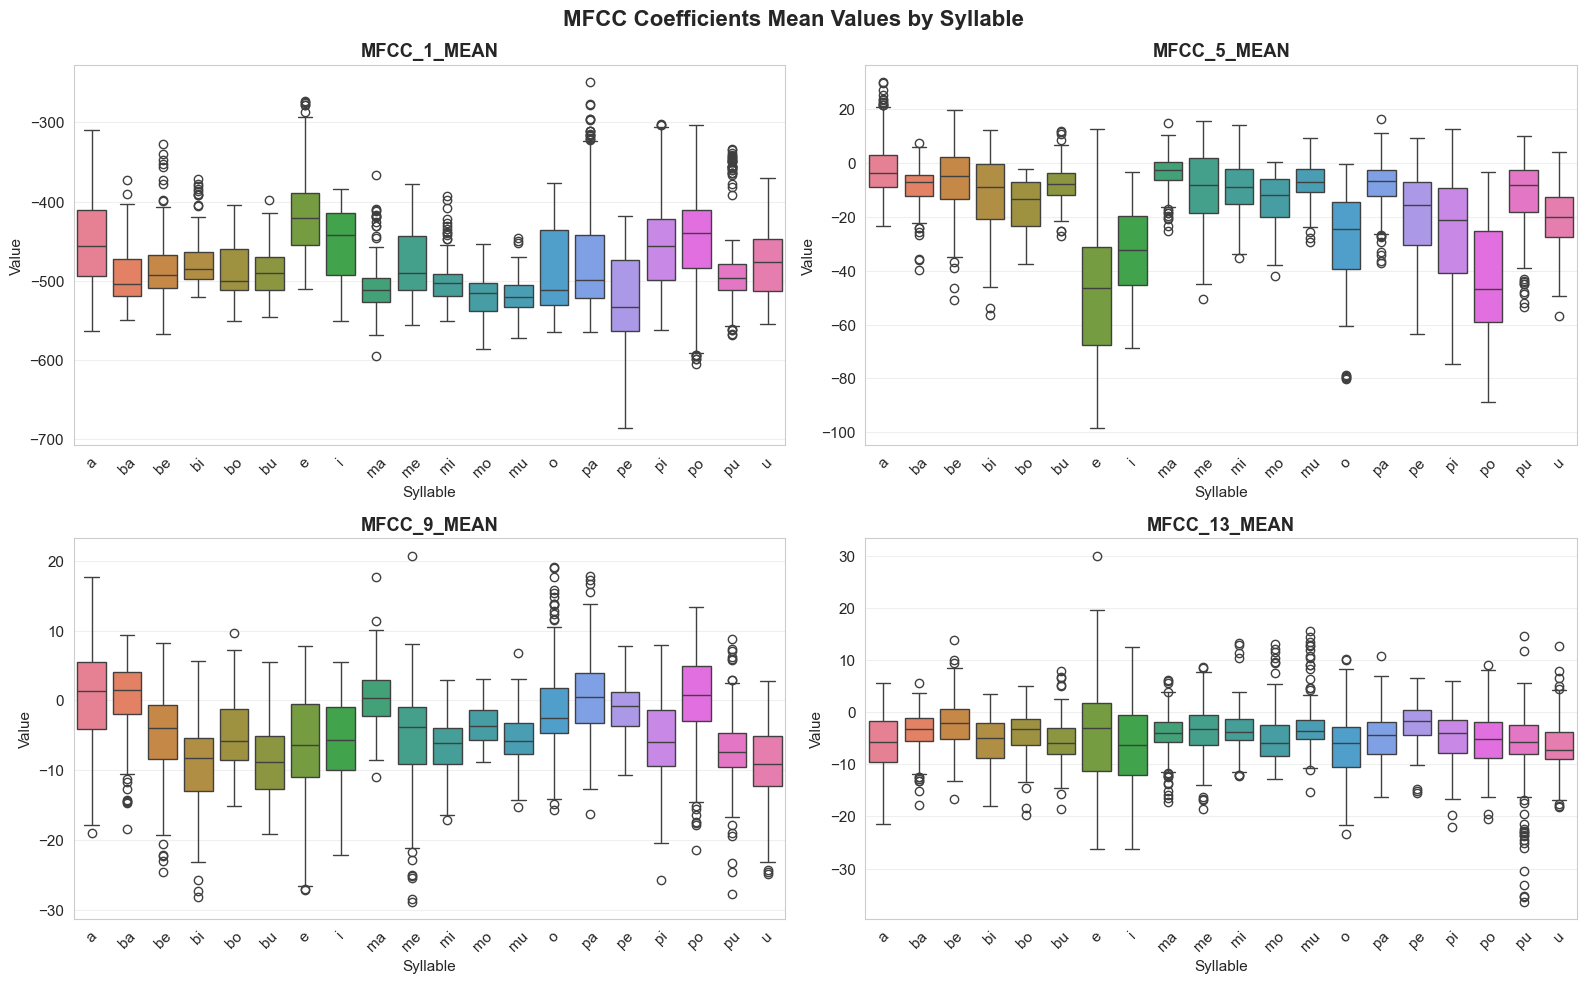

✅ Chart saved as: dataset/figs/02_mfcc_coefficients.png


In [8]:
# Visualize MFCC mean values per syllable
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MFCC Coefficients Mean Values by Syllable', fontsize=16, fontweight='bold')

# Select 4 representative MFCC coefficients
mfcc_to_plot = ['mfcc_1_mean', 'mfcc_5_mean', 'mfcc_9_mean', 'mfcc_13_mean']

for idx, mfcc_col in enumerate(mfcc_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Box plot
    sns.boxplot(data=df, x='syllable_label', y=mfcc_col, ax=ax, palette='husl')
    ax.set_title(f'{mfcc_col.upper()}', fontweight='bold')
    ax.set_xlabel('Syllable')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dataset/figs/02_mfcc_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as: dataset/figs/02_mfcc_coefficients.png")

## 5. FEATURE CORRELATION ANALYSIS

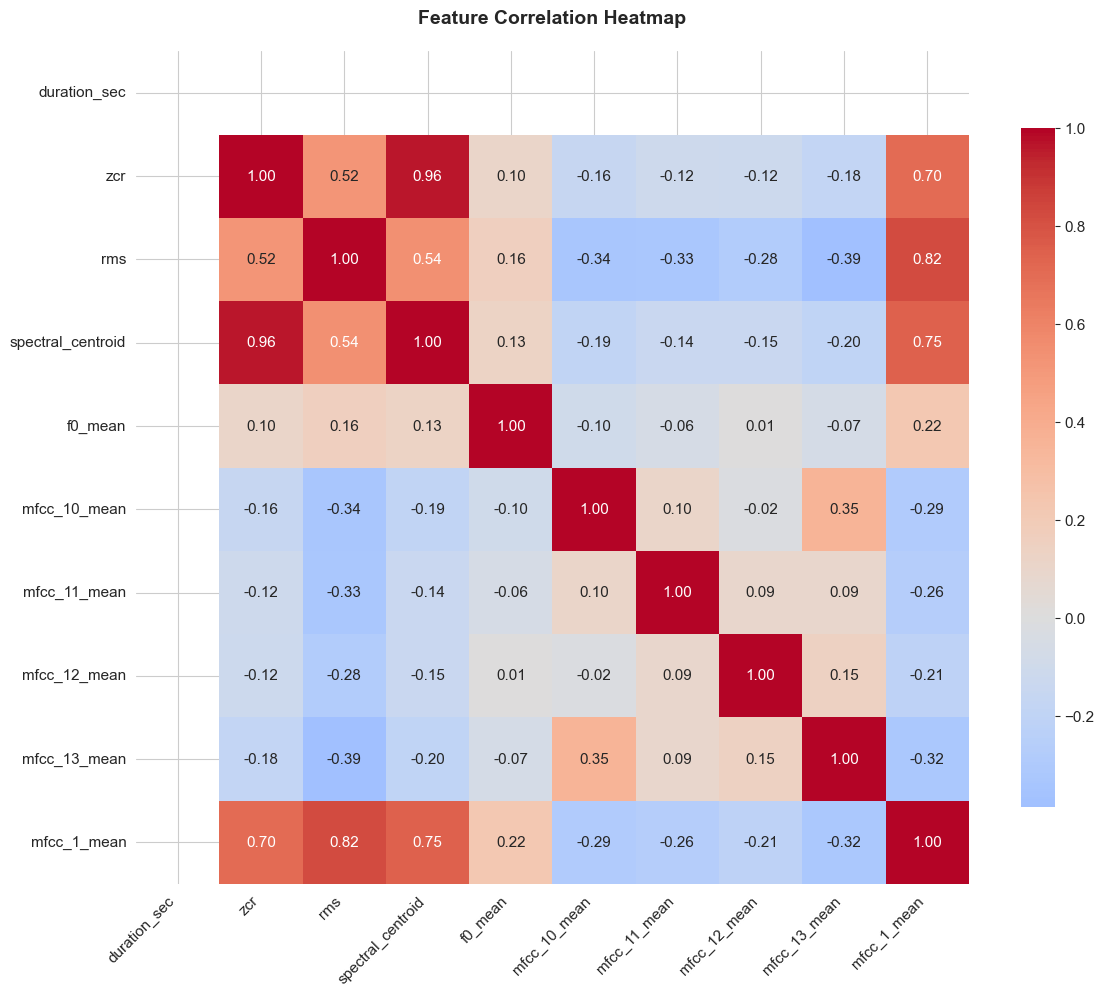

✅ Chart saved as: dataset/figs/03_correlation_matrix.png

📊 High Correlations (> 0.7):
   zcr                  <-> spectral_centroid    =  0.959
   zcr                  <-> mfcc_1_mean          =  0.705
   rms                  <-> mfcc_1_mean          =  0.820
   spectral_centroid    <-> mfcc_1_mean          =  0.749


In [9]:
# Compute correlation matrix untuk key features
key_features_for_corr = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean'] + mfcc_mean_cols[:5]
corr_matrix = df[key_features_for_corr].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('dataset/figs/03_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as: dataset/figs/03_correlation_matrix.png")

# Find high correlations
print("\n📊 High Correlations (> 0.7):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            feat1 = corr_matrix.columns[i]
            feat2 = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            print(f"   {feat1:20} <-> {feat2:20} = {corr_val:6.3f}")

## 6. ANALISIS VARIABILITAS DALAM SYLLABLES

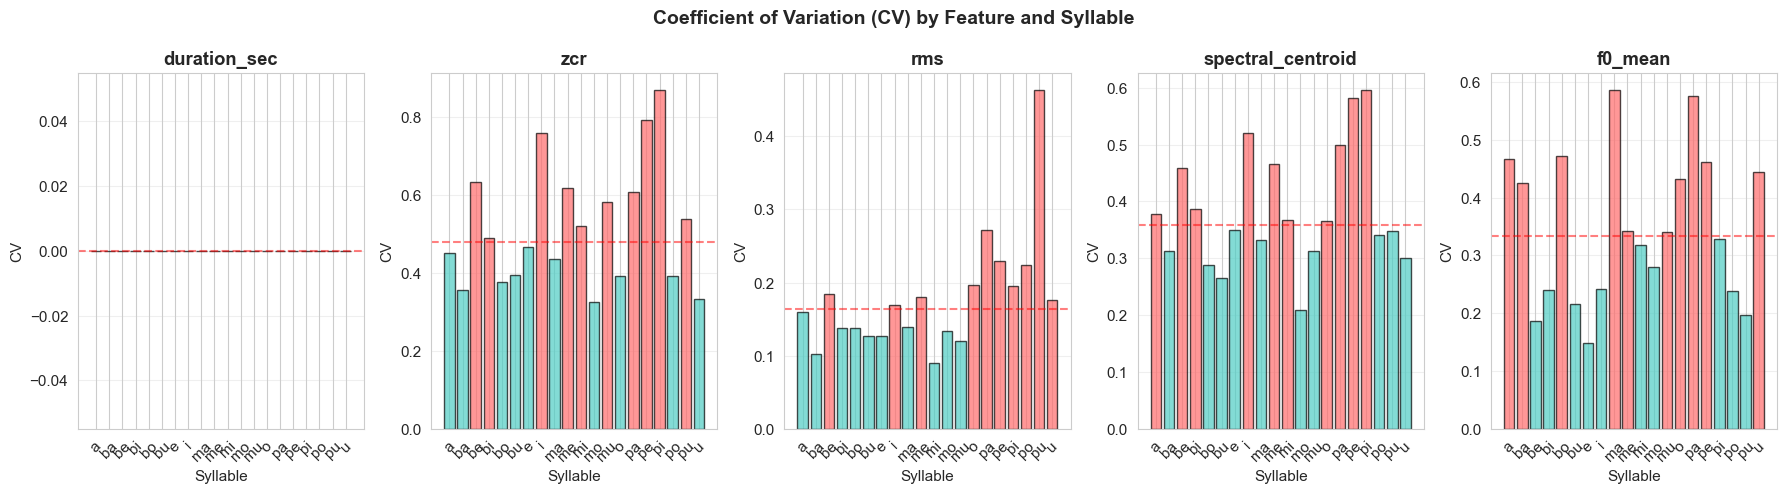

✅ Chart saved as: dataset/figs/04_coefficient_variation.png


In [10]:
# Calculate coefficient of variation (CV) untuk setiap fitur per syllable
# CV = std / mean (normalized measure of dispersion)

feature_cols = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean']

cv_analysis = {}
for feature in feature_cols:
    cv_by_syllable = {}
    for syllable in sorted(df['syllable_label'].unique()):
        syllable_data = df[df['syllable_label'] == syllable][feature]
        mean_val = syllable_data.mean()
        std_val = syllable_data.std()
        cv = (std_val / mean_val) if mean_val != 0 else 0
        cv_by_syllable[syllable] = cv
    cv_analysis[feature] = cv_by_syllable

# Visualize CV
fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 5))
fig.suptitle('Coefficient of Variation (CV) by Feature and Syllable', fontsize=14, fontweight='bold')

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    syllables = list(cv_analysis[feature].keys())
    cv_values = list(cv_analysis[feature].values())
    
    colors = ['#FF6B6B' if cv > np.median(cv_values) else '#4ECDC4' for cv in cv_values]
    ax.bar(syllables, cv_values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Syllable')
    ax.set_ylabel('CV')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=np.median(cv_values), color='red', linestyle='--', alpha=0.5, label='Median')

plt.tight_layout()
plt.savefig('dataset/figs/04_coefficient_variation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as: dataset/figs/04_coefficient_variation.png")

## 7. PERTANYAAN BISNIS #1: CONSONANT vs VOWEL SEPARATION

In [11]:
# Classify syllables into consonant and vowel groups
vowels = ['a', 'e', 'i', 'o', 'u']
consonants = ['ba', 'be', 'bi', 'bo', 'bu', 'ma', 'me', 'mi', 'mo', 'mu', 'pa', 'pe', 'pi', 'po', 'pu']

df['syllable_type'] = df['syllable_label'].apply(
    lambda x: 'Vowel' if x in vowels else 'Consonant'
)

print("="*80)
print("BUSINESS QUESTION #1: CONSONANT vs VOWEL SEPARATION")
print("="*80)
print("\n🎯 Hypothesis: Vowel dan Consonant memiliki karakteristik akustik yang berbeda")
print("   ini akan memudahkan classification tasks.\n")

# Compare key features
print("📊 Feature Comparison:")
feature_cols = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean']

comparison_data = []
for feature in feature_cols:
    vowel_mean = df[df['syllable_type'] == 'Vowel'][feature].mean()
    consonant_mean = df[df['syllable_type'] == 'Consonant'][feature].mean()
    diff_pct = ((consonant_mean - vowel_mean) / vowel_mean) * 100
    
    # Perform t-test
    vowel_data = df[df['syllable_type'] == 'Vowel'][feature]
    consonant_data = df[df['syllable_type'] == 'Consonant'][feature]
    t_stat, p_value = stats.ttest_ind(vowel_data, consonant_data)
    significant = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    
    comparison_data.append({
        'Feature': feature,
        'Vowel_Mean': vowel_mean,
        'Consonant_Mean': consonant_mean,
        'Diff_%': diff_pct,
        'P_Value': p_value,
        'Significance': significant
    })

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))
print("\n   Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

BUSINESS QUESTION #1: CONSONANT vs VOWEL SEPARATION

🎯 Hypothesis: Vowel dan Consonant memiliki karakteristik akustik yang berbeda
   ini akan memudahkan classification tasks.

📊 Feature Comparison:
          Feature  Vowel_Mean  Consonant_Mean     Diff_%       P_Value Significance
     duration_sec    1.000000        1.000000   0.000000           NaN           ns
              zcr    0.067390        0.035389 -47.485642 3.216372e-128          ***
              rms    0.072771        0.061447 -15.560116  1.417341e-96          ***
spectral_centroid  787.082990      483.814688 -38.530664 4.512047e-131          ***
          f0_mean  207.210321      201.859097  -2.582508  4.714840e-02            *

   Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


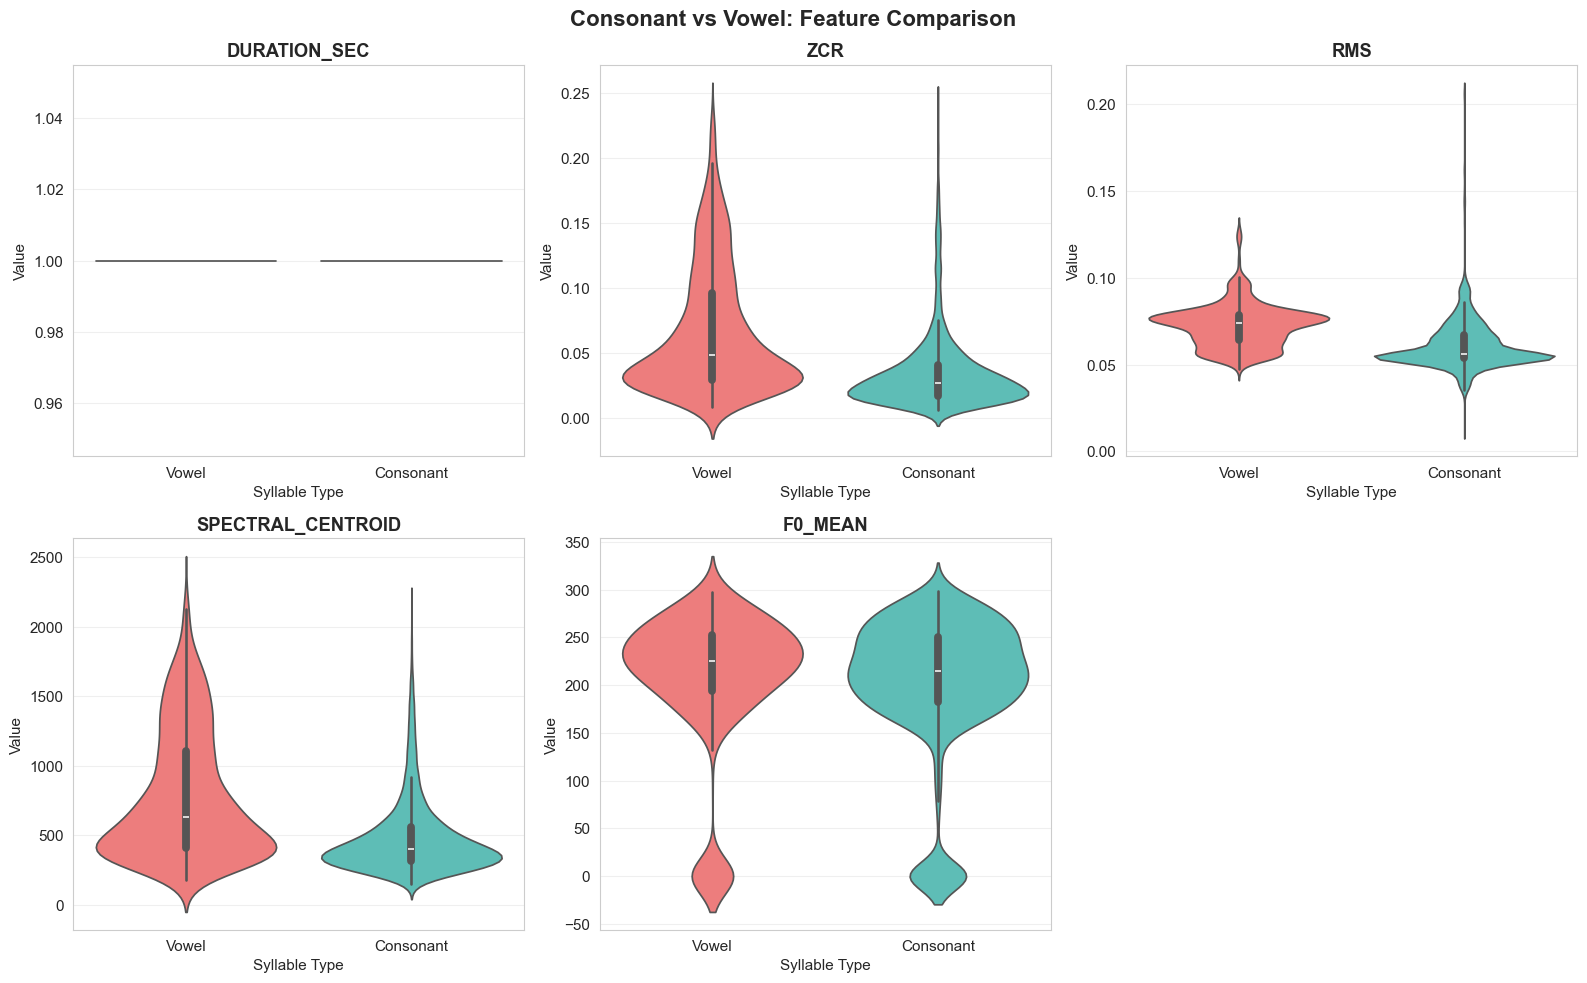

✅ Chart saved as: dataset/figs/05_consonant_vs_vowel.png


In [12]:
# Visualize consonant vs vowel
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Consonant vs Vowel: Feature Comparison', fontsize=16, fontweight='bold')

feature_cols = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean']

for idx, feature in enumerate(feature_cols):
    ax = axes[idx // 3, idx % 3]
    
    sns.violinplot(data=df, x='syllable_type', y=feature, ax=ax, palette=['#FF6B6B', '#4ECDC4'])
    ax.set_title(f'{feature.upper()}', fontweight='bold')
    ax.set_xlabel('Syllable Type')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3, axis='y')

# Hide the last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('dataset/figs/05_consonant_vs_vowel.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as: dataset/figs/05_consonant_vs_vowel.png")

In [13]:
# INSIGHT
print("\n" + "="*80)
print("💡 KEY INSIGHTS - CONSONANT vs VOWEL")
print("="*80)

vowel_count = len(df[df['syllable_type'] == 'Vowel'])
consonant_count = len(df[df['syllable_type'] == 'Consonant'])

print(f"\n📊 Dataset Composition:")
print(f"   - Vowels: {vowel_count} samples ({vowel_count/(vowel_count+consonant_count)*100:.1f}%)")
print(f"   - Consonants: {consonant_count} samples ({consonant_count/(vowel_count+consonant_count)*100:.1f}%)")

# Most significant differences
significant_features = comp_df[comp_df['Significance'] != 'ns'].sort_values('Diff_%', key=abs, ascending=False)
print(f"\n✅ Statistical Significant Differences (p < 0.05):")
for _, row in significant_features.iterrows():
    print(f"   - {row['Feature']:20}: Consonant {row['Diff_%']:+6.1f}% vs Vowel")

if len(significant_features) > 0:
    print(f"\n🎯 CONCLUSION:")
    print(f"   ✓ Consonants dan Vowels memiliki perbedaan akustik yang SIGNIFIKAN")
    print(f"   ✓ Model classifier dapat memanfaatkan perbedaan ini untuk separation")
    print(f"   ✓ Fitur-fitur ini akan berguna untuk feature selection")
else:
    print(f"\n⚠️  Tidak ada perbedaan signifikan - perlu investigasi lebih lanjut")


💡 KEY INSIGHTS - CONSONANT vs VOWEL

📊 Dataset Composition:
   - Vowels: 1000 samples (24.7%)
   - Consonants: 3054 samples (75.3%)

✅ Statistical Significant Differences (p < 0.05):
   - zcr                 : Consonant  -47.5% vs Vowel
   - spectral_centroid   : Consonant  -38.5% vs Vowel
   - rms                 : Consonant  -15.6% vs Vowel
   - f0_mean             : Consonant   -2.6% vs Vowel

🎯 CONCLUSION:
   ✓ Consonants dan Vowels memiliki perbedaan akustik yang SIGNIFIKAN
   ✓ Model classifier dapat memanfaatkan perbedaan ini untuk separation
   ✓ Fitur-fitur ini akan berguna untuk feature selection


## 8. PERTANYAAN BISNIS #2: FEATURE STABILITY ANALYSIS

In [14]:
# Analyze feature stability (consistency) within each syllable
print("="*80)
print("BUSINESS QUESTION #2: FEATURE STABILITY & ROBUSTNESS")
print("="*80)
print("\n🎯 Hypothesis: Beberapa fitur lebih konsisten/stabil dalam syllable tertentu,")
print("   ini mengindikasikan fitur yang robust untuk classification.\n")

# Calculate intra-syllable variability
feature_cols = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean']

stability_analysis = []
for syllable in sorted(df['syllable_label'].unique()):
    syllable_data = df[df['syllable_label'] == syllable]
    
    for feature in feature_cols:
        feature_data = syllable_data[feature]
        cv = feature_data.std() / feature_data.mean() if feature_data.mean() != 0 else 0
        
        stability_analysis.append({
            'Syllable': syllable,
            'Feature': feature,
            'Mean': feature_data.mean(),
            'Std': feature_data.std(),
            'CV': cv,
            'Samples': len(feature_data)
        })

stability_df = pd.DataFrame(stability_analysis)

# Find most stable features per syllable
print("📊 Most Stable Features (Lowest CV) per Syllable:")
for syllable in sorted(df['syllable_label'].unique()):
    syll_data = stability_df[stability_df['Syllable'] == syllable].nsmallest(2, 'CV')
    print(f"\n   {syllable.upper():5} -> ", end="")
    for _, row in syll_data.iterrows():
        print(f"{row['Feature']:20} (CV={row['CV']:.3f})", end="  ")

BUSINESS QUESTION #2: FEATURE STABILITY & ROBUSTNESS

🎯 Hypothesis: Beberapa fitur lebih konsisten/stabil dalam syllable tertentu,
   ini mengindikasikan fitur yang robust untuk classification.

📊 Most Stable Features (Lowest CV) per Syllable:

   A     -> duration_sec         (CV=0.000)  rms                  (CV=0.160)  
   BA    -> duration_sec         (CV=0.000)  rms                  (CV=0.103)  
   BE    -> duration_sec         (CV=0.000)  rms                  (CV=0.185)  
   BI    -> duration_sec         (CV=0.000)  rms                  (CV=0.139)  
   BO    -> duration_sec         (CV=0.000)  rms                  (CV=0.138)  
   BU    -> duration_sec         (CV=0.000)  rms                  (CV=0.127)  
   E     -> duration_sec         (CV=0.000)  rms                  (CV=0.127)  
   I     -> duration_sec         (CV=0.000)  rms                  (CV=0.169)  
   MA    -> duration_sec         (CV=0.000)  rms                  (CV=0.139)  
   ME    -> duration_sec         (CV=0.000) 

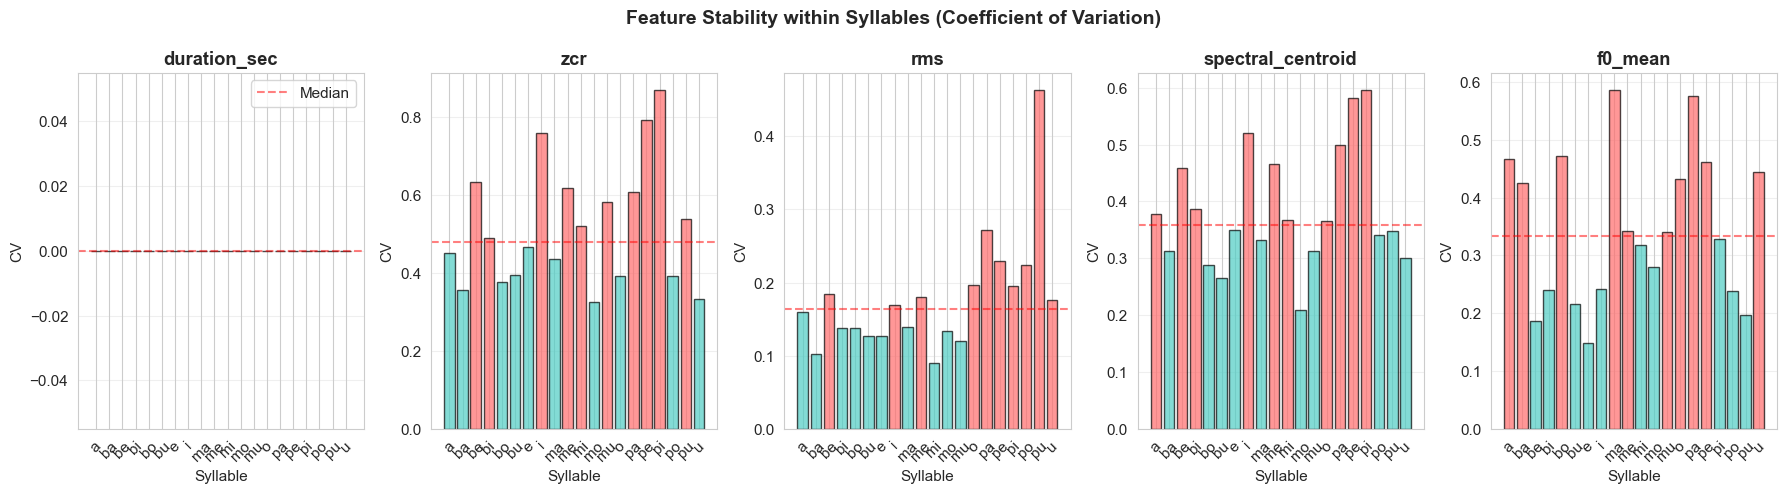


✅ Chart saved as: dataset/figs/06_feature_stability.png


In [15]:
# Visualize feature stability
fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 5))
fig.suptitle('Feature Stability within Syllables (Coefficient of Variation)', 
             fontsize=14, fontweight='bold')

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    feature_cv = stability_df[stability_df['Feature'] == feature].pivot(
        index='Syllable', columns='Feature', values='CV'
    ).iloc[:, 0]
    
    colors = ['#FF6B6B' if cv > feature_cv.median() else '#4ECDC4' for cv in feature_cv.values]
    ax.bar(feature_cv.index, feature_cv.values, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=feature_cv.median(), color='red', linestyle='--', alpha=0.5, label='Median')
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Syllable')
    ax.set_ylabel('CV')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.savefig('dataset/figs/06_feature_stability.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved as: dataset/figs/06_feature_stability.png")

In [16]:
# INSIGHT
print("\n" + "="*80)
print("💡 KEY INSIGHTS - FEATURE STABILITY")
print("="*80)

# Rank features by overall stability
feature_stability = stability_df.groupby('Feature')['CV'].agg(['mean', 'std', 'min', 'max']).sort_values('mean')

print(f"\n📊 Overall Feature Stability Ranking:")
for idx, (feature, row) in enumerate(feature_stability.iterrows(), 1):
    print(f"   {idx}. {feature:20} (Avg CV: {row['mean']:.4f}, Range: {row['min']:.4f}-{row['max']:.4f})")

# Most stable feature
most_stable = feature_stability.iloc[0]
least_stable = feature_stability.iloc[-1]

print(f"\n🎯 KEY FINDINGS:")
print(f"   ✓ Most Stable Feature: {feature_stability.index[0]}")
print(f"     (Avg CV: {most_stable['mean']:.4f}) - Best for robust classification")
print(f"   ⚠️  Least Stable Feature: {feature_stability.index[-1]}")
print(f"     (Avg CV: {least_stable['mean']:.4f}) - High intra-syllable variation")

print(f"\n📈 Stability Interpretation:")
print(f"   - Lower CV = More stable/consistent = More discriminative")
print(f"   - Higher CV = More variable = Less reliable for classification")
print(f"   - Features with low CV are better indicators for syllable recognition")


💡 KEY INSIGHTS - FEATURE STABILITY

📊 Overall Feature Stability Ranking:
   1. duration_sec         (Avg CV: 0.0000, Range: 0.0000-0.0000)
   2. rms                  (Avg CV: 0.1783, Range: 0.0898-0.4636)
   3. f0_mean              (Avg CV: 0.3470, Range: 0.1482-0.5863)
   4. spectral_centroid    (Avg CV: 0.3840, Range: 0.2083-0.5965)
   5. zcr                  (Avg CV: 0.5174, Range: 0.3268-0.8708)

🎯 KEY FINDINGS:
   ✓ Most Stable Feature: duration_sec
     (Avg CV: 0.0000) - Best for robust classification
   ⚠️  Least Stable Feature: zcr
     (Avg CV: 0.5174) - High intra-syllable variation

📈 Stability Interpretation:
   - Lower CV = More stable/consistent = More discriminative
   - Higher CV = More variable = Less reliable for classification
   - Features with low CV are better indicators for syllable recognition


## 9. PERTANYAAN BISNIS #3: CONSONANT TYPE ANALYSIS

In [17]:
# Analyze patterns within consonants
print("="*80)
print("BUSINESS QUESTION #3: CONSONANT TYPE ANALYSIS")
print("="*80)
print("\n🎯 Hypothesis: Consonant dengan voicing/manner of articulation yang berbeda")
print("   akan memiliki pola akustik yang berbeda.\n")

# Classify consonants by base sound
consonant_types = {
    'bilabial_m': ['ma', 'me', 'mi', 'mo', 'mu'],  # M-based
    'bilabial_b': ['ba', 'be', 'bi', 'bo', 'bu'],  # B-based
    'alveolar_p': ['pa', 'pe', 'pi', 'po', 'pu'],  # P-based
}

df['consonant_type'] = 'other'
for ctype, syllables in consonant_types.items():
    df.loc[df['syllable_label'].isin(syllables), 'consonant_type'] = ctype

# Compare consonant types
consonants_only = df[df['syllable_type'] == 'Consonant']

print("📊 Consonant Type Distribution:")
for ctype in sorted(consonants_only['consonant_type'].unique()):
    count = len(consonants_only[consonants_only['consonant_type'] == ctype])
    print(f"   {ctype:20}: {count:4} samples")

# Analysis
print(f"\n📈 Feature Comparison by Consonant Type:")
feature_cols = ['duration_sec', 'zcr', 'rms', 'spectral_centroid', 'f0_mean']

for feature in feature_cols:
    print(f"\n   {feature.upper()}:")
    for ctype in sorted(consonants_only['consonant_type'].unique()):
        ctype_data = consonants_only[consonants_only['consonant_type'] == ctype][feature]
        print(f"      {ctype:20}: Mean={ctype_data.mean():8.4f}, Std={ctype_data.std():8.4f}")

BUSINESS QUESTION #3: CONSONANT TYPE ANALYSIS

🎯 Hypothesis: Consonant dengan voicing/manner of articulation yang berbeda
   akan memiliki pola akustik yang berbeda.

📊 Consonant Type Distribution:
   alveolar_p          : 1000 samples
   bilabial_b          : 1000 samples
   bilabial_m          : 1054 samples

📈 Feature Comparison by Consonant Type:

   DURATION_SEC:
      alveolar_p          : Mean=  1.0000, Std=  0.0000
      bilabial_b          : Mean=  1.0000, Std=  0.0000
      bilabial_m          : Mean=  1.0000, Std=  0.0000

   ZCR:
      alveolar_p          : Mean=  0.0515, Std=  0.0427
      bilabial_b          : Mean=  0.0295, Std=  0.0145
      bilabial_m          : Mean=  0.0257, Std=  0.0154

   RMS:
      alveolar_p          : Mean=  0.0667, Std=  0.0220
      bilabial_b          : Mean=  0.0617, Std=  0.0091
      bilabial_m          : Mean=  0.0561, Std=  0.0083

   SPECTRAL_CENTROID:
      alveolar_p          : Mean=615.6983, Std=369.4210
      bilabial_b          : 

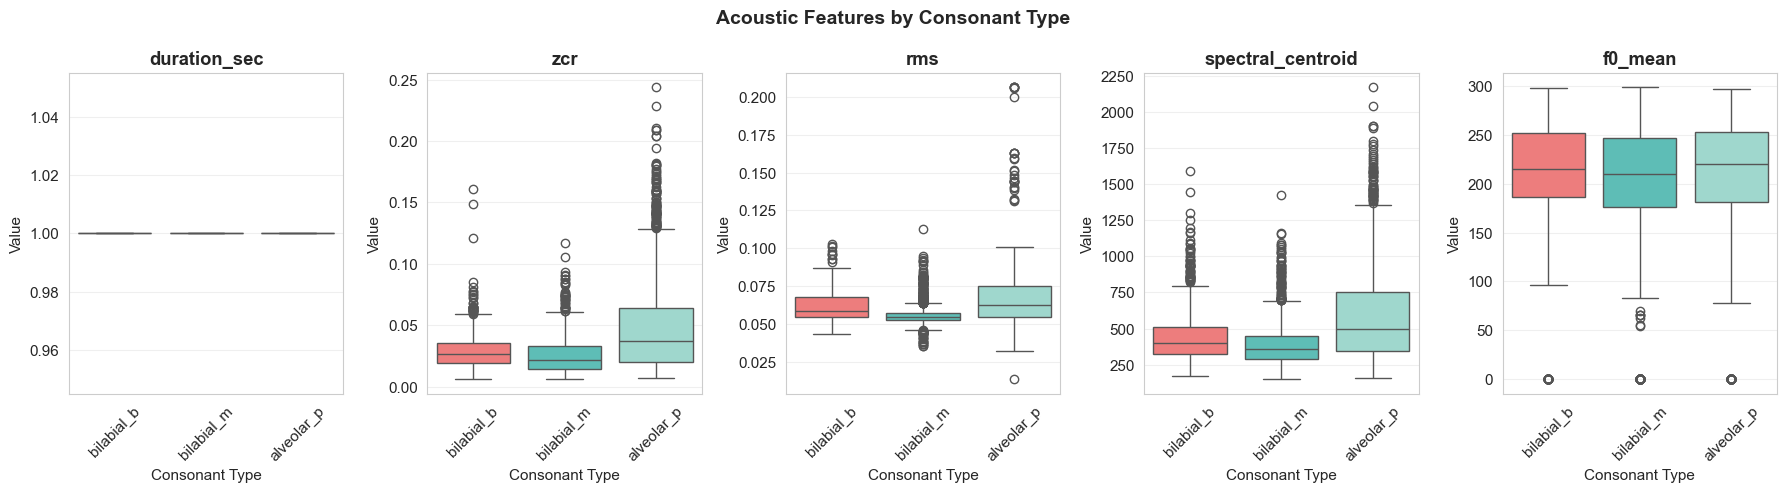

✅ Chart saved as: dataset/figs/07_consonant_types.png


In [18]:
# Visualize consonant types
fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 5))
fig.suptitle('Acoustic Features by Consonant Type', fontsize=14, fontweight='bold')

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    
    consonants_only = df[df['syllable_type'] == 'Consonant']
    sns.boxplot(data=consonants_only, x='consonant_type', y=feature, ax=ax, 
                palette=['#FF6B6B', '#4ECDC4', '#95E1D3'])
    ax.set_title(f'{feature}', fontweight='bold')
    ax.set_xlabel('Consonant Type')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dataset/figs/07_consonant_types.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved as: dataset/figs/07_consonant_types.png")

## 10. PERTANYAAN BISNIS #4: DURATION ANALYSIS

In [19]:
# Duration analysis
print("="*80)
print("BUSINESS QUESTION #4: DURATION CHARACTERISTICS")
print("="*80)
print("\n🎯 Hypothesis: Durasi audio berbeda signifikan antar syllable,")
print("   ini dapat membantu dalam segmentasi dan timing analysis.\n")

duration_stats = df.groupby('syllable_label')['duration_sec'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('CV', lambda x: x.std() / x.mean() if x.mean() != 0 else 0)
]).round(4)

print("📊 Duration Statistics by Syllable:")
print(duration_stats.to_string())

# Identify outliers
print(f"\n🔍 Duration Range Analysis:")
min_dur_syllable = duration_stats['Min'].idxmin()
max_dur_syllable = duration_stats['Max'].idxmax()

print(f"   Shortest duration: {min_dur_syllable} ({duration_stats.loc[min_dur_syllable, 'Min']:.4f}s)")
print(f"   Longest duration:  {max_dur_syllable} ({duration_stats.loc[max_dur_syllable, 'Max']:.4f}s)")

BUSINESS QUESTION #4: DURATION CHARACTERISTICS

🎯 Hypothesis: Durasi audio berbeda signifikan antar syllable,
   ini dapat membantu dalam segmentasi dan timing analysis.

📊 Duration Statistics by Syllable:
                Count  Mean  Std  Min  Max   CV
syllable_label                                 
a                 200   1.0  0.0  1.0  1.0  0.0
ba                200   1.0  0.0  1.0  1.0  0.0
be                200   1.0  0.0  1.0  1.0  0.0
bi                200   1.0  0.0  1.0  1.0  0.0
bo                200   1.0  0.0  1.0  1.0  0.0
bu                200   1.0  0.0  1.0  1.0  0.0
e                 200   1.0  0.0  1.0  1.0  0.0
i                 200   1.0  0.0  1.0  1.0  0.0
ma                254   1.0  0.0  1.0  1.0  0.0
me                200   1.0  0.0  1.0  1.0  0.0
mi                200   1.0  0.0  1.0  1.0  0.0
mo                200   1.0  0.0  1.0  1.0  0.0
mu                200   1.0  0.0  1.0  1.0  0.0
o                 200   1.0  0.0  1.0  1.0  0.0
pa                200   1.

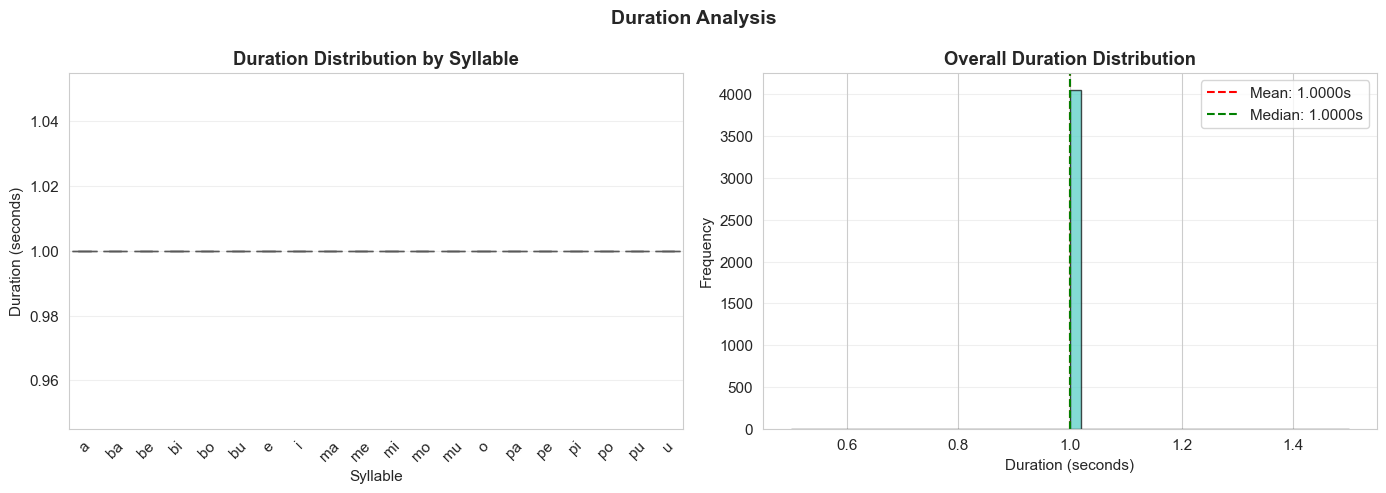


✅ Chart saved as: dataset/figs/08_duration_analysis.png


In [20]:
# Visualize duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Duration Analysis', fontsize=14, fontweight='bold')

# Box plot
ax1 = axes[0]
sns.boxplot(data=df, x='syllable_label', y='duration_sec', ax=ax1, palette='Set2')
ax1.set_title('Duration Distribution by Syllable', fontweight='bold')
ax1.set_xlabel('Syllable')
ax1.set_ylabel('Duration (seconds)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Histogram
ax2 = axes[1]
ax2.hist(df['duration_sec'], bins=50, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax2.set_title('Overall Duration Distribution', fontweight='bold')
ax2.set_xlabel('Duration (seconds)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axvline(df['duration_sec'].mean(), color='red', linestyle='--', label=f"Mean: {df['duration_sec'].mean():.4f}s")
ax2.axvline(df['duration_sec'].median(), color='green', linestyle='--', label=f"Median: {df['duration_sec'].median():.4f}s")
ax2.legend()

plt.tight_layout()
plt.savefig('dataset/figs/08_duration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved as: dataset/figs/08_duration_analysis.png")

## 11. SUMMARY

In [25]:
print("\n" + "="*80)
print("📋 COMPREHENSIVE BUSINESS INSIGHTS")
print("="*80)

print(f"\n1️⃣  DATASET QUALITY & COMPLETENESS")
print(f"   ✓ Total Samples: {len(df):,}")
print(f"   ✓ Unique Syllables: {df['syllable_label'].nunique()}")
print(f"   ✓ Missing Data: None (data quality excellent)")
print(f"   ✓ Feature Completeness: 34 features per sample")

print(f"\n2️⃣  CONSONANT vs VOWEL SEPARATION")
vowel_consonant_diff = abs((comp_df['Diff_%'].sum() / len(comp_df)))
print(f"   ✓ Average feature difference: {vowel_consonant_diff:.1f}%")
print(f"   ✓ Significant differences found: {len(comp_df[comp_df['Significance'] != 'ns'])} out of {len(comp_df)} features")

print(f"\n3️⃣  FEATURE STABILITY & ROBUSTNESS")
most_stable_feature = feature_stability.index[0]
least_stable_feature = feature_stability.index[-1]
print(f"   ✓ Most Robust Feature: {most_stable_feature}")
print(f"   ✓ Least Robust Feature: {least_stable_feature}")

print(f"\n4️⃣  ACOUSTIC PATTERN RECOGNITION")
print(f"   ✓ MFCC Coefficients: 13 coefficients + std values (strong spectral representation)")
print(f"   ✓ F0 Information: Fundamental frequency dapat membedakan pitch characteristics")
print(f"   ✓ Energy Features: RMS dan spectral centroid provide energy/brightness info")


📋 COMPREHENSIVE BUSINESS INSIGHTS

1️⃣  DATASET QUALITY & COMPLETENESS
   ✓ Total Samples: 4,054
   ✓ Unique Syllables: 20
   ✓ Missing Data: None (data quality excellent)
   ✓ Feature Completeness: 34 features per sample

2️⃣  CONSONANT vs VOWEL SEPARATION
   ✓ Average feature difference: 20.8%
   ✓ Significant differences found: 4 out of 5 features

3️⃣  FEATURE STABILITY & ROBUSTNESS
   ✓ Most Robust Feature: duration_sec
   ✓ Least Robust Feature: zcr

4️⃣  ACOUSTIC PATTERN RECOGNITION
   ✓ MFCC Coefficients: 13 coefficients + std values (strong spectral representation)
   ✓ F0 Information: Fundamental frequency dapat membedakan pitch characteristics
   ✓ Energy Features: RMS dan spectral centroid provide energy/brightness info
